In [2]:
import os
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (classification_report, roc_curve,
                             auc, ConfusionMatrixDisplay, roc_auc_score,
                             cohen_kappa_score)

In [5]:
import warnings

warnings.filterwarnings("ignore")

In [3]:
from src.config.dir_config import Process_Dir
df = pd.read_csv(Process_Dir / 'onlinefraud_cleaned.csv')
df.head(10)

,hour_of_day,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.0,0.00,C1231006815,M1979787155,1,0.00,0.00,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.0,0.00,C1666544295,M2044282225,1,0.00,0.00,0
2,1,TRANSFER,181.00,181.00,0.00,0.0,0.00,C1305486145,C553264065,0,0.00,181.00,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.0,0.00,C840083671,C38997010,0,0.00,21363.00,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.0,0.00,C2048537720,M1230701703,1,0.00,0.00,0
5,1,PAYMENT,7817.71,53860.00,46042.29,0.0,0.00,C90045638,M573487274,1,0.00,0.00,0
6,1,PAYMENT,7107.77,183195.00,176087.23,0.0,0.00,C154988899,M408069119,1,0.00,0.00,0
7,1,PAYMENT,7861.64,176087.23,168225.59,0.0,0.00,C1912850431,M633326333,1,0.00,0.00,0
8,1,PAYMENT,4024.36,2671.00,0.00,0.0,0.00,C1265012928,M1176932104,1,1353.36,0.00,0
9,1,DEBIT,5337.77,41720.00,36382.23,41898.0,40348.79,C712410124,C195600860,0,0.00,6886.98,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [4]:
df = pd.get_dummies(df, columns= ['type'], drop_first= True, dtype= int)
df

,hour_of_day,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,nameOrig,nameDest,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,160296.36,0.00,0.00,C1231006815,M1979787155,1,0.0,0.000000e+00,0,0,0,1,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,C1666544295,M2044282225,1,0.0,0.000000e+00,0,0,0,1,0
2,1,181.00,181.00,0.00,0.00,0.00,C1305486145,C553264065,0,0.0,1.810000e+02,1,0,0,0,1
3,1,181.00,181.00,0.00,21182.00,0.00,C840083671,C38997010,0,0.0,2.136300e+04,1,1,0,0,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,C2048537720,M1230701703,1,0.0,0.000000e+00,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,23,339682.13,339682.13,0.00,0.00,339682.13,C786484425,C776919290,0,0.0,0.000000e+00,1,1,0,0,0
6362616,23,6311409.28,6311409.28,0.00,0.00,0.00,C1529008245,C1881841831,0,0.0,6.311409e+06,1,0,0,0,1
6362617,23,6311409.28,6311409.28,0.00,68488.84,6379898.11,C1162922333,C1365125890,0,0.0,1.000000e-02,1,1,0,0,0
6362618,23,850002.52,850002.52,0.00,0.00,0.00,C1685995037,C2080388513,0,0.0,8.500025e+05,1,0,0,0,1


In [10]:
X = df.drop(['nameOrig', 'nameDest'], axis= 1)
y = X.pop('isFraud')

# train+val and test
x_temp, x_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=42
)

# train and validation
x_train, x_val, y_train, y_val = train_test_split(
    x_temp,
    y_temp,
    test_size=0.1765,  # ~15% total
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

# Fit only on training data
x_train_scaled = scaler.fit_transform(x_train)

# Use the same scaler for val and test
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

In [11]:
x_train_scaled.shape, x_val_scaled.shape, x_test_scaled.shape

((4453674, 13), (954553, 13), (954393, 13))

In [10]:
lr_model = LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    )

rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    )

cat_model = CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )

lgbm_model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    )

# Logistic Regression
lr_model.fit(x_train_scaled, y_train)

# Random Forest
rf_model.fit(x_train_scaled, y_train)

# XGBoost
xgb_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    verbose= False
)

# CatBoost
cat_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
)

# Light GBM
lgbm_model.fit(
    x_train_scaled,
    y_train,
    eval_set=[(x_val_scaled, y_val)],
    eval_metric='auc',
)

[LightGBM] [Info] Number of positive: 5749, number of negative: 4447925
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.094150 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1825
[LightGBM] [Info] Number of data points in the train set: 4453674, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,10
,learning_rate,0.1
,n_estimators,200
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


#### Save models

In [ ]:
os.makedirs("main_models", exist_ok=True)

models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost" : xgb_model,
    "LightGBM": lgbm_model,
    "CatBoost": cat_model
}

for name, model in models.items():
    filename = f"main_models/{name}.pkl"
    joblib.dump(model, filename)
    print(f"Saved: {filename}")

print("All models saved!")

Saved: main_models/Logistic Regression.pkl
Saved: main_models/Random Forest.pkl
Saved: main_models/XGBoost.pkl
Saved: main_models/LightGBM.pkl
Saved: main_models/CatBoost.pkl
All models saved!


#### Load models

In [14]:
lr_model = joblib.load("main_models/Logistic Regression.pkl")
rf_model = joblib.load("main_models/Random Forest.pkl")
xgb_model = joblib.load("main_models/XGBoost.pkl")
cat_model = joblib.load("main_models/CatBoost.pkl")
lgbm_model = joblib.load("main_models/LightGBM.pkl")

#### Evaluate

In [27]:
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost" : xgb_model,
    "CatBoost": cat_model,
    "LightGBM": lgbm_model
}

In [ ]:
for name, model in models.items():
    y_pred = model.predict(x_test_scaled)
    y_pred_proba = model.predict_proba(x_val_scaled)[:, 1]
    y_pred_kappa = cohen_kappa_score(y_test, y_pred)
    auc_score = roc_auc_score(y_val, y_pred_proba)

    print(name)
    print(f"kappa score: {y_pred_kappa:.4f}")
    print(f"auc score: {auc_score:.4f}")
    print(
        classification_report(
            y_test,
            y_pred,
            digits= 4,
            labels=[0, 1],
            target_names=['Non-Fraud', 'Fraud']
        )
    )
    print()

Logistic Regression
kappa score: 0.0461
auc score: 0.9910
              precision    recall  f1-score   support

   Non-Fraud     0.9999    0.9522    0.9755    953161
       Fraud     0.0249    0.9432    0.0485      1232

    accuracy                         0.9522    954393
   macro avg     0.5124    0.9477    0.5120    954393
weighted avg     0.9987    0.9522    0.9743    954393


Random Forest
kappa score: 0.9988
auc score: 0.9996
              precision    recall  f1-score   support

   Non-Fraud     1.0000    1.0000    1.0000    953161
       Fraud     1.0000    0.9976    0.9988      1232

    accuracy                         1.0000    954393
   macro avg     1.0000    0.9988    0.9994    954393
weighted avg     1.0000    1.0000    1.0000    954393


XGBoost
kappa score: 0.9371
auc score: 1.0000
              precision    recall  f1-score   support

   Non-Fraud     1.0000    0.9999    0.9999    953161
       Fraud     0.9124    0.9635    0.9372      1232

    accuracy            

#### Find best Thresholds for each model

In [21]:
def find_best_threshold(y_true, y_pred_score):
    thresholds = np.arange(0.01, 1.0, 0.01)

    best_f1 = 0
    best_threshold = 0

    for t in thresholds:
        y_pred = (y_pred_score >= t).astype(int)

        f1 = f1_score(y_true, y_pred)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    return best_threshold, best_f1

Logistic Regression
kappa score: 0.4247
best threshold: 0.99
              precision    recall  f1-score   support

   Non-Fraud     0.9995    0.9983    0.9989    953161
       Fraud     0.3232    0.6234    0.4257      1232

    accuracy                         0.9978    954393
   macro avg     0.6614    0.8108    0.7123    954393
weighted avg     0.9986    0.9978    0.9982    954393




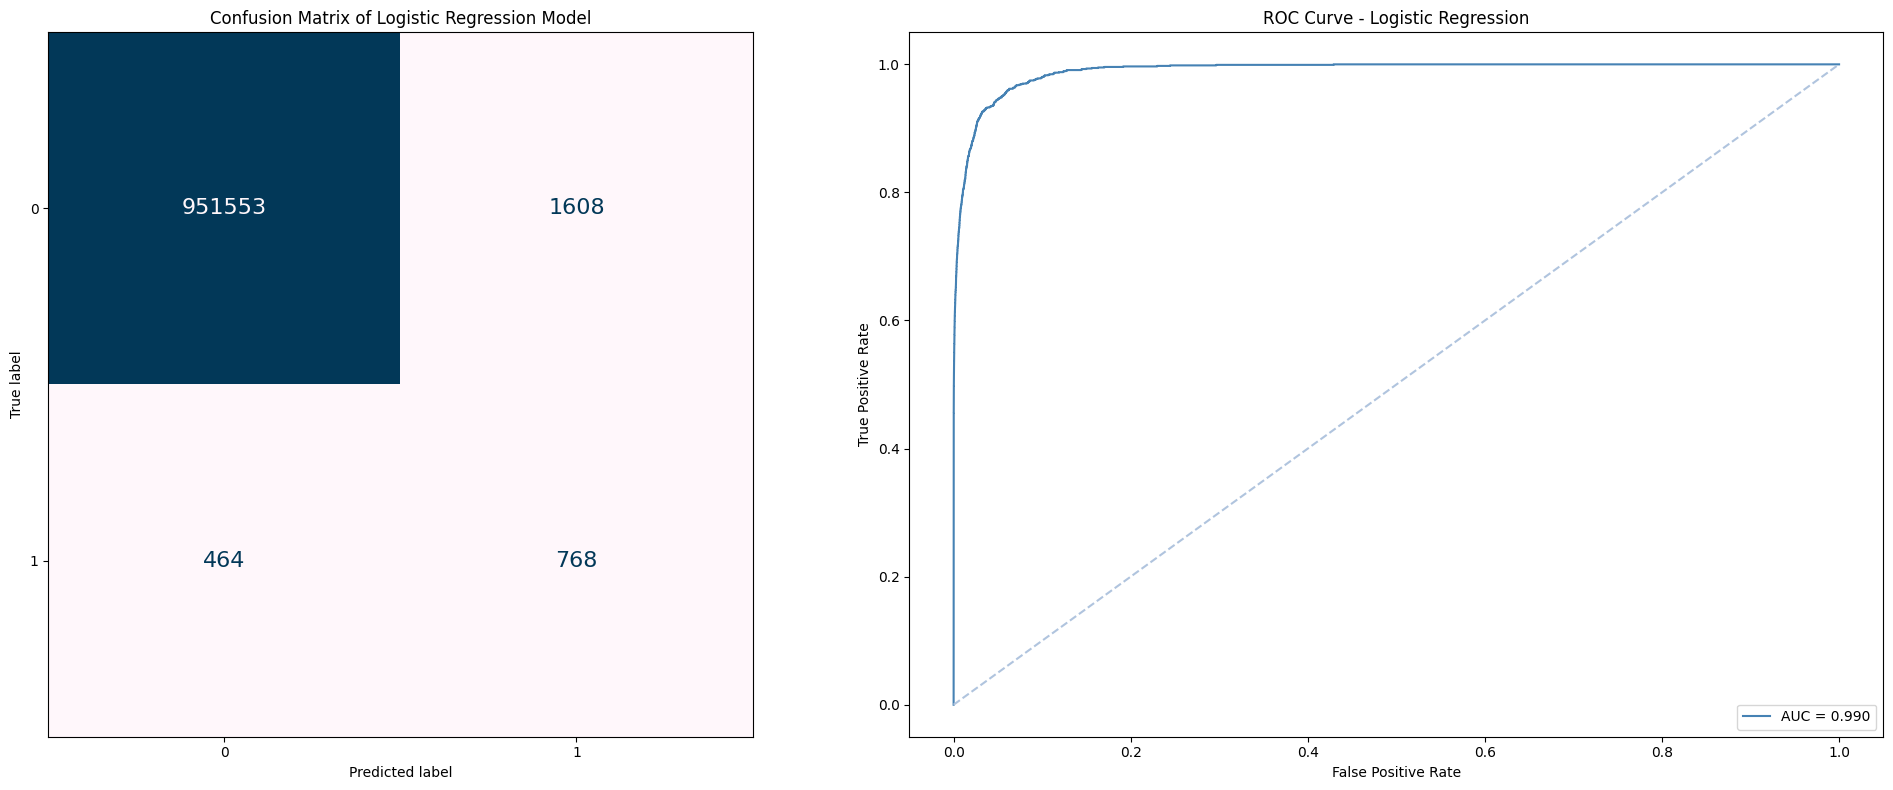

Random Forest
kappa score: 0.9988
best threshold: 0.18
              precision    recall  f1-score   support

   Non-Fraud     1.0000    1.0000    1.0000    953161
       Fraud     1.0000    0.9976    0.9988      1232

    accuracy                         1.0000    954393
   macro avg     1.0000    0.9988    0.9994    954393
weighted avg     1.0000    1.0000    1.0000    954393




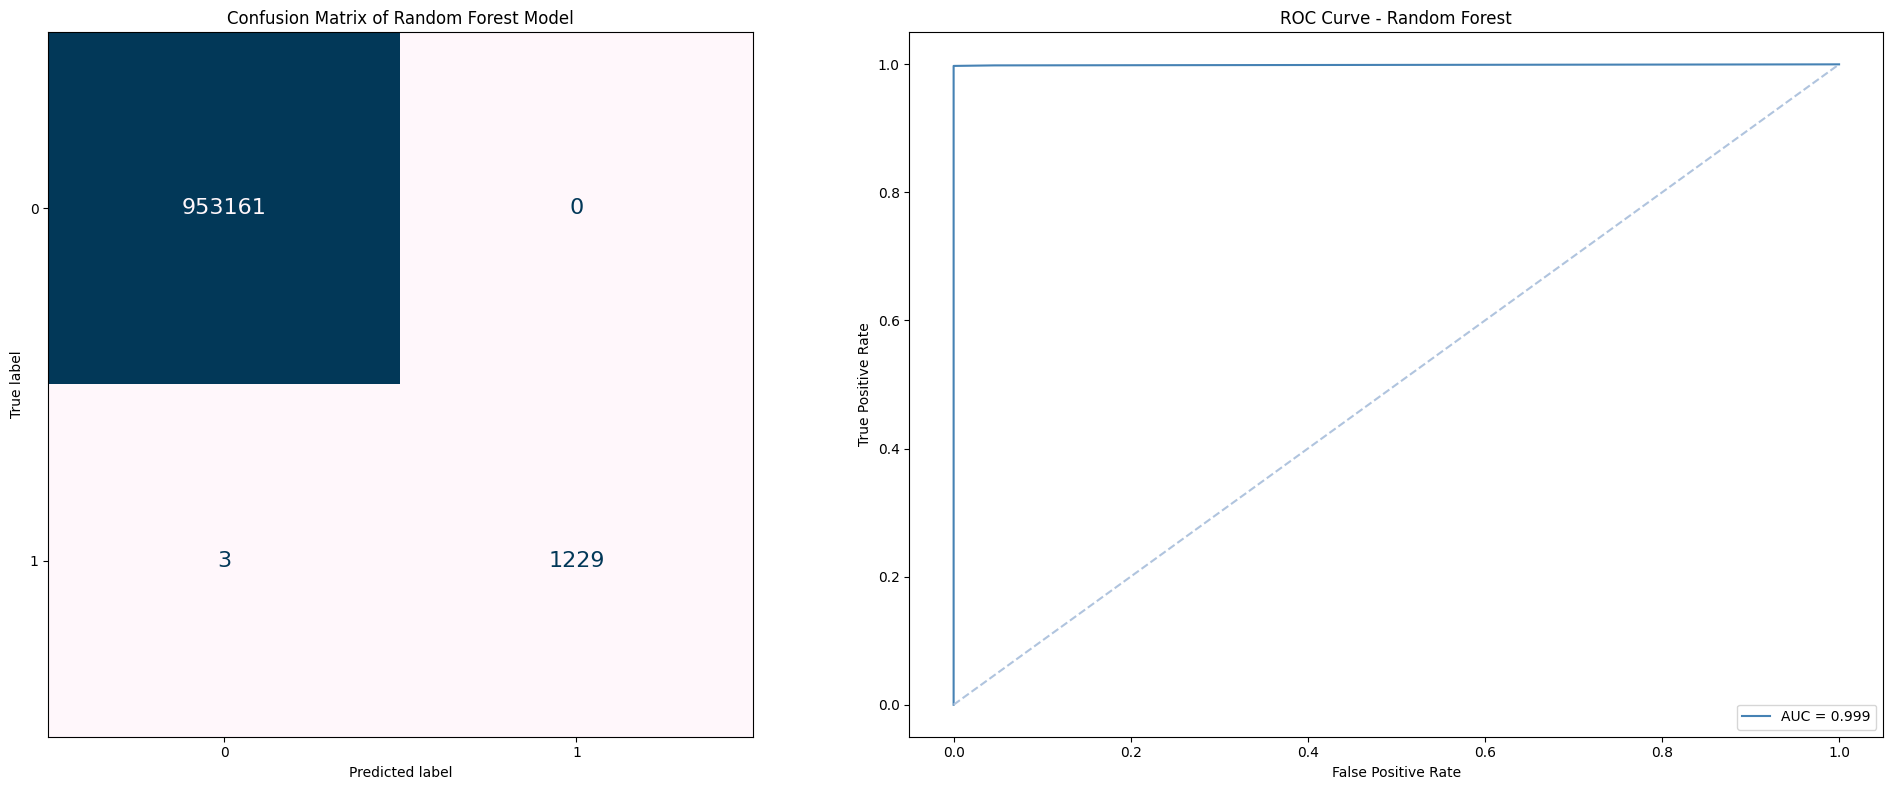

XGBoost
kappa score: 0.9457
best threshold: 0.90
              precision    recall  f1-score   support

   Non-Fraud     0.9999    1.0000    0.9999    953161
       Fraud     0.9653    0.9269    0.9458      1232

    accuracy                         0.9999    954393
   macro avg     0.9826    0.9635    0.9728    954393
weighted avg     0.9999    0.9999    0.9999    954393




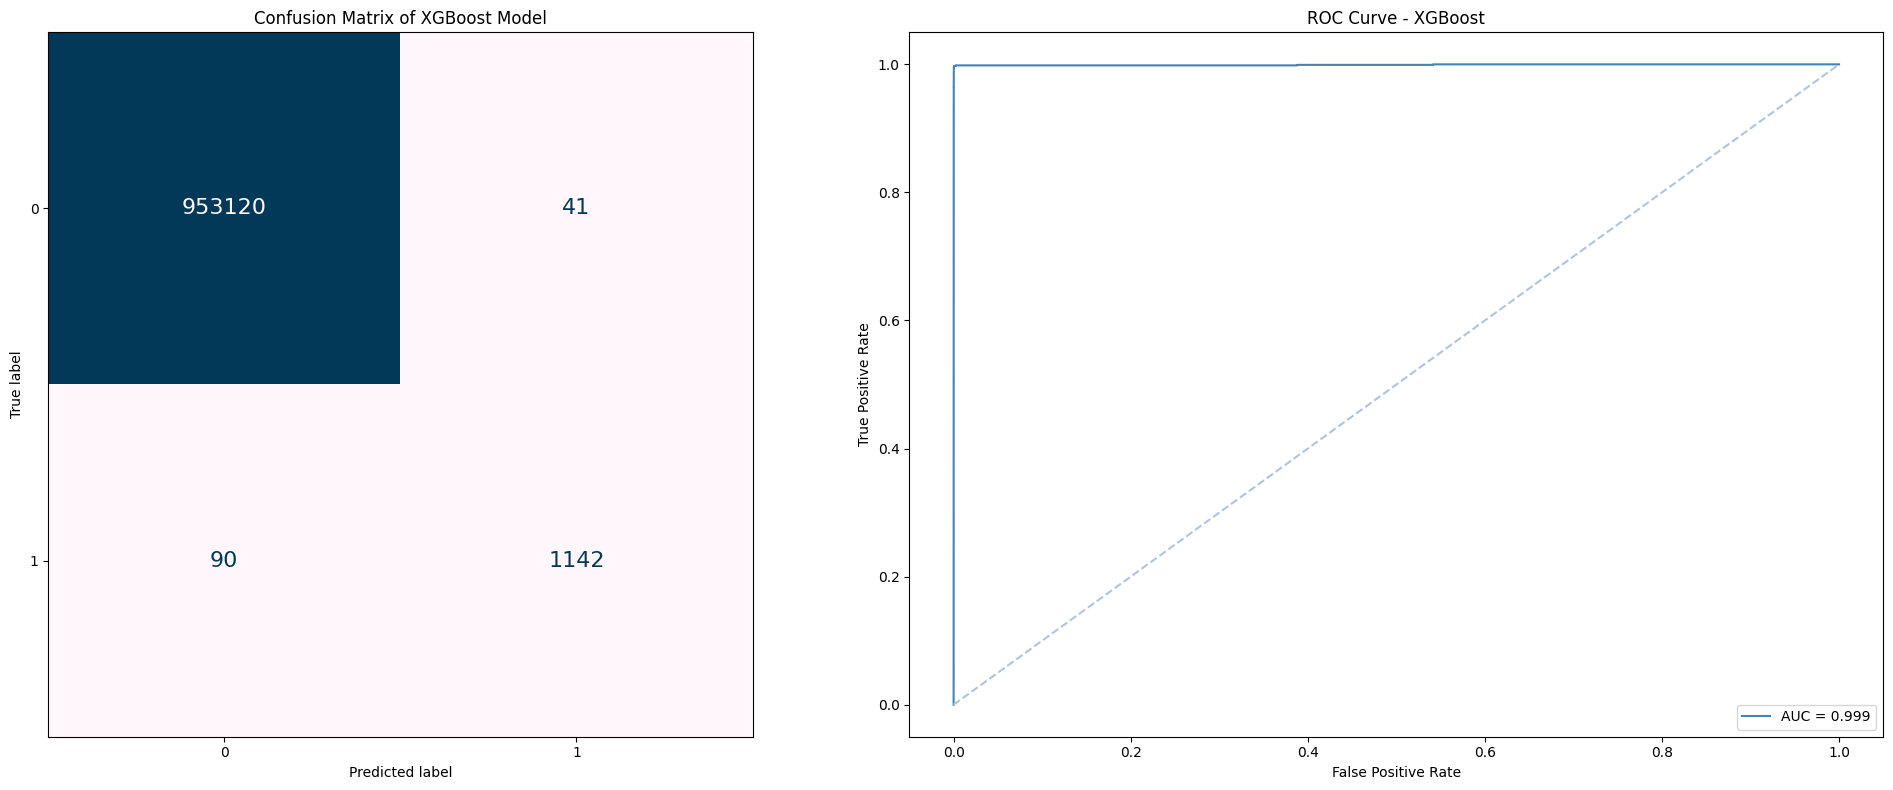

CatBoost
kappa score: 0.9988
best threshold: 0.83
              precision    recall  f1-score   support

   Non-Fraud     1.0000    1.0000    1.0000    953161
       Fraud     1.0000    0.9976    0.9988      1232

    accuracy                         1.0000    954393
   macro avg     1.0000    0.9988    0.9994    954393
weighted avg     1.0000    1.0000    1.0000    954393




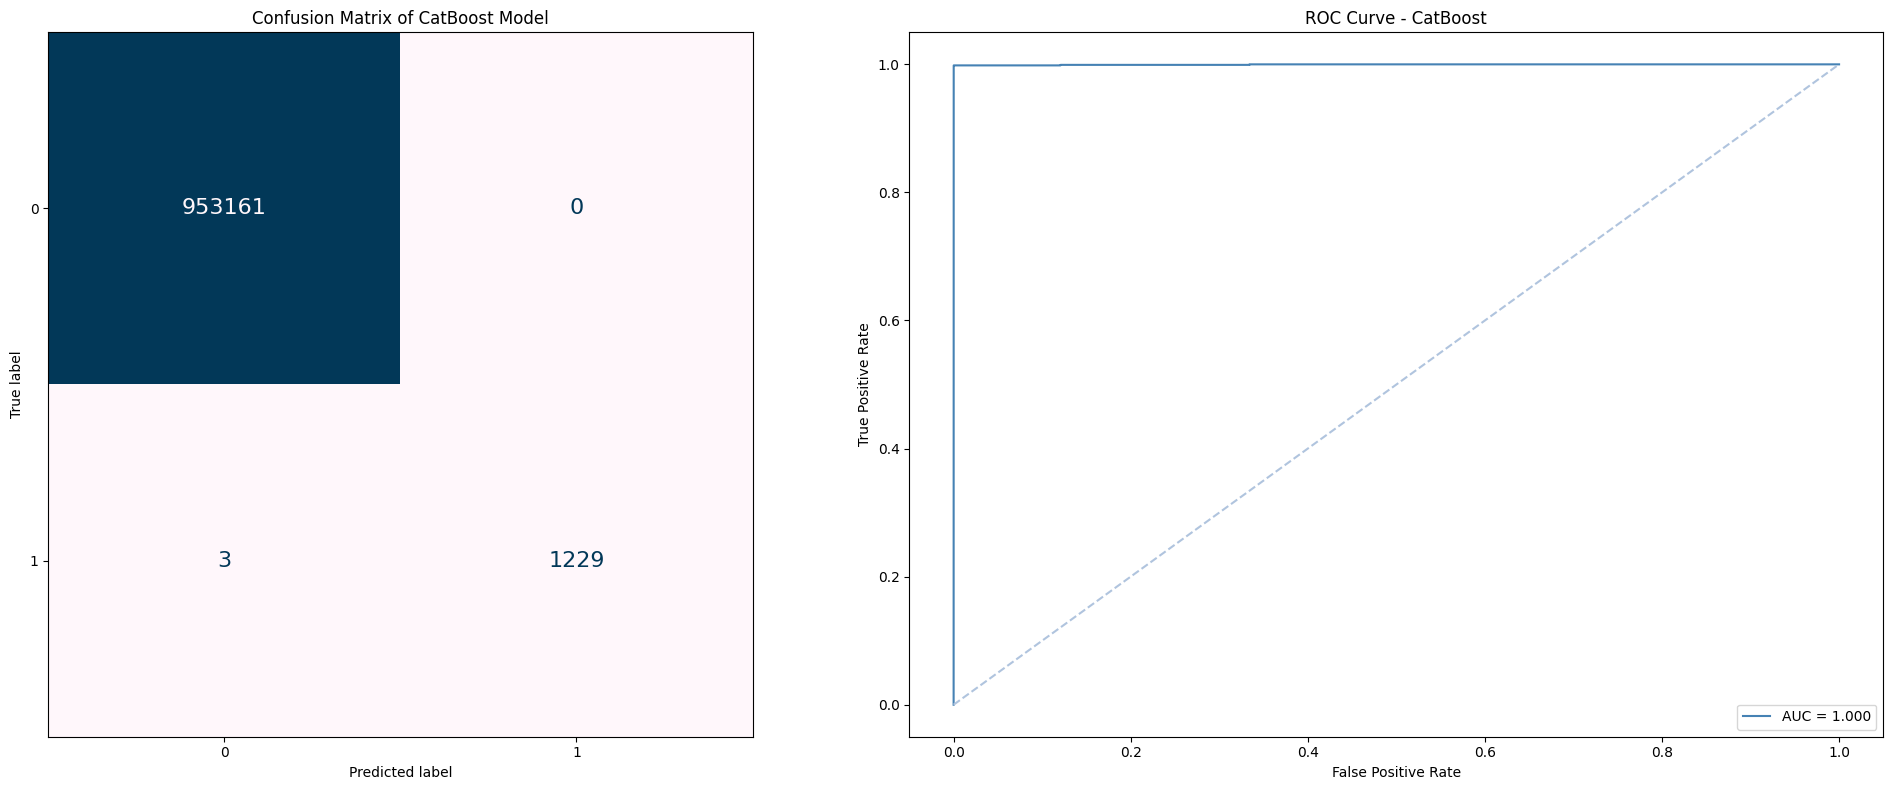

LightGBM
kappa score: 0.9984
best threshold: 0.95
              precision    recall  f1-score   support

   Non-Fraud     1.0000    1.0000    1.0000    953161
       Fraud     0.9992    0.9976    0.9984      1232

    accuracy                         1.0000    954393
   macro avg     0.9996    0.9988    0.9992    954393
weighted avg     1.0000    1.0000    1.0000    954393




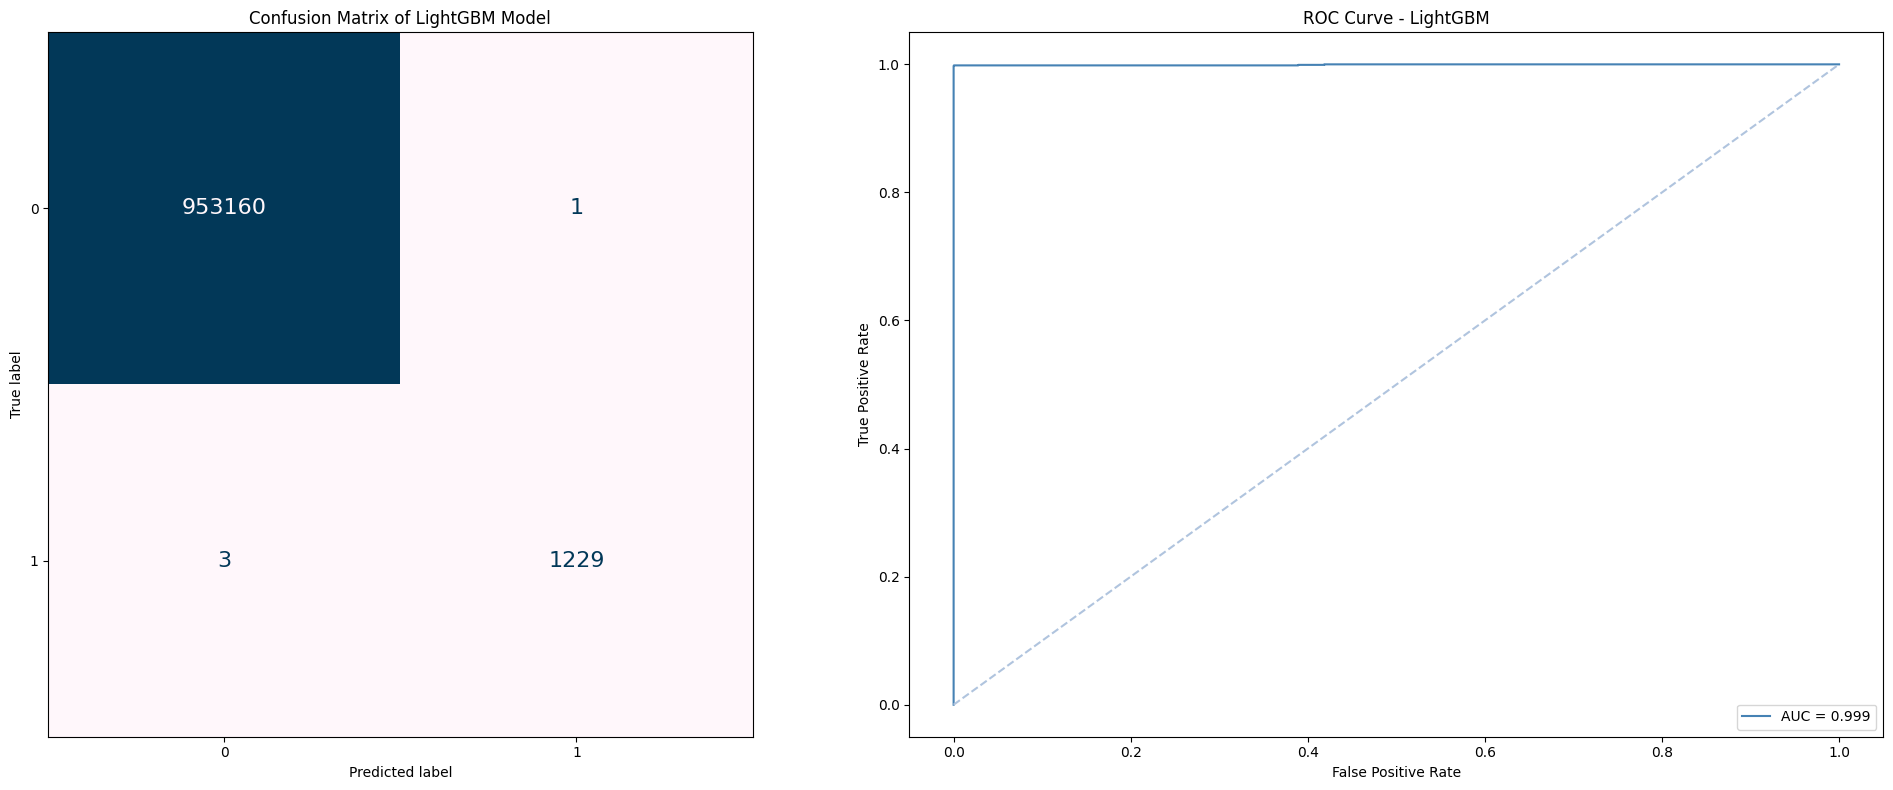

In [30]:
for name, model in models.items():
    y_pred_score = model.predict_proba(x_test_scaled)[:, 1]
    best_threshold, best_f1 = find_best_threshold(y_test, y_pred_score)
    y_pred = (y_pred_score >= best_threshold).astype(int)
    y_pred_kappa = cohen_kappa_score(y_test, y_pred)

    print(name)
    print(f"kappa score: {y_pred_kappa:.4f}")
    print(f"best threshold: {best_threshold:.2f}")
    print(
        classification_report(
            y_test,
            y_pred,
            digits= 4,
            labels=[0, 1],
            target_names=['Non-Fraud', 'Fraud']
        )
    )
    print()

    fig, ax = plt.subplots(1, 2, figsize=(20,8))

    # Confusion Matrix
    ax[0].set_title(f'Confusion Matrix of {name} Model')
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        colorbar=False,
        values_format='',
        cmap='PuBu',
        ax=ax[0],
        text_kw={'fontsize': 16}
    )
    ax[0].grid(False)

    # ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_score)
    roc_auc = auc(fpr, tpr)

    ax[1].set_title(f'ROC Curve - {name}')
    ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}', c='steelblue')
    ax[1].plot([0,1], [0,1], '--', c='lightsteelblue')
    ax[1].legend(loc='lower right')
    ax[1].set_ylabel('True Positive Rate')
    ax[1].set_xlabel('False Positive Rate')

    plt.tight_layout()
    plt.show()

#### The table of before and after apply thresholds

| Model | AUC | Kappa (before) | Precision (before) | Recall (before) | F1 (before) | Best Threshold | Kappa (after) | Precision (after) | Recall (after) | F1 (after) |
|---------|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|---------:|
| Logistic Regression | 0.9910 | 0.0461 | 0.0249 | 0.9432 | 0.0485 | 0.99 | 0.4247 | 0.3232 | 0.6234 | 0.4257 |
| Random Forest | 0.9996 | 0.9988 | 1.0000 | 0.9976 | 0.9988 | 0.18 | 0.9988 | 1.0000 | 0.9976 | 0.9988 |
| XGBoost | 1.0000 | 0.9371 | 0.9124 | 0.9635 | 0.9372 | 0.90 | 0.9457 | 0.9653 | 0.9269 | 0.9458 |
| CatBoost | 1.0000 | 0.9303 | 0.8711 | 0.9984 | 0.9304 | 0.83 | 0.9988 | 1.0000 | 0.9976 | 0.9988 |
| LightGBM | 1.0000 | 0.9963 | 0.9951 | 0.9976 | 0.9964 | 0.95 | 0.9984 | 0.9992 | 0.9976 | 0.9984 |

- Note: Logistic Regression doesn't have feature importance

In [23]:
# Random Forest
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
7   errorBalanceOrig    0.387425
3     newbalanceOrig    0.154141
2      oldbalanceOrg    0.126491
1             amount    0.071526
6   is_Merchant_Dest    0.056228
12     type_TRANSFER    0.044514
11      type_PAYMENT    0.038059
9      type_CASH_OUT    0.025252
8   errorBalanceDest    0.025230
0        hour_of_day    0.025041
5     newbalanceDest    0.023288
4     oldbalanceDest    0.021863
10        type_DEBIT    0.000942


In [24]:
# XGBoost
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
3     newbalanceOrig    0.582636
11      type_PAYMENT    0.144221
6   is_Merchant_Dest    0.139586
7   errorBalanceOrig    0.050740
8   errorBalanceDest    0.013404
10        type_DEBIT    0.013393
9      type_CASH_OUT    0.013200
1             amount    0.011632
12     type_TRANSFER    0.010658
2      oldbalanceOrg    0.007746
0        hour_of_day    0.006552
4     oldbalanceDest    0.004029
5     newbalanceDest    0.002204


In [31]:
# CatBoost
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': cat_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
7   errorBalanceOrig   37.928309
3     newbalanceOrig   22.291501
2      oldbalanceOrg    8.627264
9      type_CASH_OUT    6.495872
1             amount    5.311306
12     type_TRANSFER    4.526940
4     oldbalanceDest    4.496670
8   errorBalanceDest    3.970466
0        hour_of_day    2.914691
5     newbalanceDest    2.622527
11      type_PAYMENT    0.754094
6   is_Merchant_Dest    0.060361
10        type_DEBIT    0.000000


In [25]:
# Light GBM
# FEATURES IMPORTANCE
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
})

print(
    importance.sort_values(
        by='importance',
        ascending=False
    )
)

             feature  importance
5     newbalanceDest         982
4     oldbalanceDest         874
7   errorBalanceOrig         826
0        hour_of_day         802
1             amount         784
8   errorBalanceDest         597
2      oldbalanceOrg         498
3     newbalanceOrig         285
12     type_TRANSFER         129
9      type_CASH_OUT          99
6   is_Merchant_Dest          91
11      type_PAYMENT          26
10        type_DEBIT           7
